In [18]:
pip install pyodbc pandas

Note: you may need to restart the kernel to use updated packages.


In [26]:
#making connection from sql to python
import pyodbc

server = r'DESKTOP-CQ4QDQT\MSSQLSERVER01'
database = 'sales_db'

conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

conn = pyodbc.connect(conn_str)
print("Connected successfully!")



Connected successfully!


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\kaviy\AppData\Local\Temp\ipykernel_10300\2728973170.py:1: SyntaxWarning: invalid escape sequence '\M'
  """import pyodbc


In [28]:
# Example query
query = "select * from Salestab"

# Load data into pandas DataFrame
df = pd.read_sql(query, conn)

# Show data
print(df)

   Product_id     Product  Quantity   Price
0           1      Laptop         5   750.0
1           2  Smartphone        10   500.0
2           3      Tablet         6   300.0
3           1      Laptop        10  1500.0
4           5     Monitor         8   200.0
5           3      Tablet         8   480.0


C:\Users\kaviy\AppData\Local\Temp\ipykernel_10300\2979188679.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [30]:
pip install sqlalchemy pyodbc

Note: you may need to restart the kernel to use updated packages.


In [1]:
from sqlalchemy import create_engine
import pandas as pd

# Build connection string
server = r'DESKTOP-CQ4QDQT\MSSQLSERVER01'
database = 'sales_db'
driver = 'ODBC Driver 17 for SQL Server'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"

# Create engine
engine = create_engine(connection_string)

# Query
query = "SELECT * FROM Salestab"

# Load into pandas DataFrame
df = pd.read_sql(query, engine)

print(df)

   Product_id     Product  Quantity   Price
0           1      Laptop         5   750.0
1           2  Smartphone        10   500.0
2           3      Tablet         6   300.0
3           1      Laptop        10  1500.0
4           5     Monitor         8   200.0
5           3      Tablet         8   480.0


In [9]:
from sqlalchemy import create_engine
import pandas as pd

# Build connection string
server = r'DESKTOP-CQ4QDQT\MSSQLSERVER01'
database = 'sales_db'
driver = 'ODBC Driver 17 for SQL Server'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"

# Create engine
engine = create_engine(connection_string)

# SQL query
query = """
SELECT 
    Product, 
    SUM(Quantity) AS total_qty, 
    SUM(Quantity * Price) AS revenue
FROM 
    sales
GROUP BY 
    Product;
"""

# Load into DataFrame
df = pd.read_sql(query, engine)

# Show results
print(df)

      Product  total_qty  revenue
0  Headphones         15   1200.0
1    Keyboard         20    900.0
2      Laptop          5   3750.0
3     Monitor          8   1600.0
4  Smartphone         10   5000.0
5      Tablet          7   2100.0


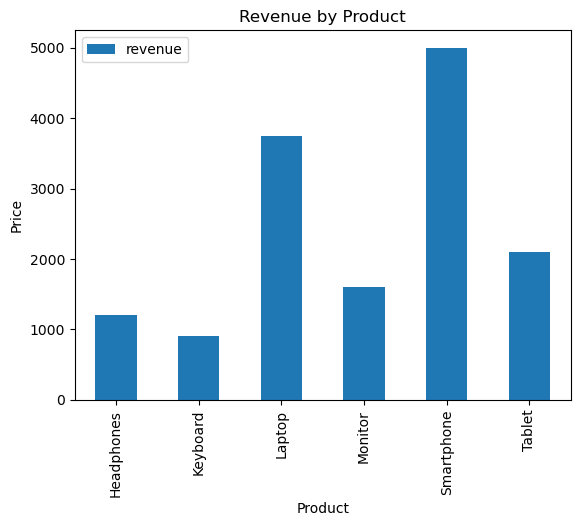

In [13]:
import matplotlib.pyplot as plt

# Simple bar plot
df.plot(kind='bar', x='Product', y='revenue')

# Add labels and title
plt.xlabel('Product')
plt.ylabel('Price')
plt.title('Revenue by Product')

# Show plot
plt.show()